In [2]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
# TODO 1: Cargar los datos de cáncer de mama
data = load_breast_cancer()

# TODO 2: Normalización
X = data.data
y = data.target
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Tensorización
X = torch.tensor(X, dtype=torch.float32) # Convertimos a tensor de tipo float32 para PyTorch (que es el tipo estándar para redes neuronales)
y = torch.tensor(y, dtype=torch.float32) # Es necesario el float porque la función de pérdida BCELoss espera probabilidades (valores entre 0 y 1) y no enteros (0 o 1)

# TODO 3: Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
# Modelo MLP sencillo
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        # TODO 4: Definir las capas del modelo
        # Primera capa lineal: de entradas a neuronas ocultas
        self.fc1 = nn.Linear(input_size, hidden_size)
        # Función de activación no lineal (ReLU es estándar)
        self.relu = nn.ReLU()
        # Segunda capa lineal: de ocultas a salida
        self.fc2 = nn.Linear(hidden_size, output_size)
        # Activación de salida: Sigmoid para obtener probabilidad entre 0 y 1
        self.sigmoid = nn.Sigmoid()

    def forward(self, x): # El metodo forward define cómo se propagan los datos a través de la red y es obligatorio en cualquier clase que herede de nn.Module
        # TODO 5: Implementar el paso forward
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.sigmoid(out)
        return out

In [5]:
# inicializamos + parámetros necesarios
input_size = X.shape[1]
hidden_size = 4
output_size = 1

# TODO 6: Crear el modelo
model = MLP(input_size, hidden_size, output_size) # Creamos una instancia de la clase MLP con los parámetros definidos arriba. Esto inicializa las capas y los pesos de la red.

# TODO 7: Define loss function and optimizer
criterion = nn.BCELoss()  # Pérdida para clasificación binaria con salida Sigmoide
optimizer = optim.Adam(model.parameters(), lr=0.01) # Learning rate de 0.01

# Training the model
num_epochs = 1000
train_losses = [] # Para almacenar la pérdida de entrenamiento en cada epoch y poder visualizarla después
test_losses = [] # Para almacenar la pérdida de prueba en cada epoch y poder visualizarla después
train_accuracy = [] # Para almacenar la precisión de entrenamiento en cada epoch y poder visualizarla después
test_accuracy = [] # Para almacenar la precisión de prueba en cada epoch y poder visualizarla después

In [6]:
# Loop entrenamiento
for epoch in range(num_epochs):
    outputs = model(X_train)
    loss = criterion(outputs, y_train.unsqueeze(1))

    # TODO 8: Backward y optimización
    optimizer.zero_grad()  # Limpiamos los gradientes anteriores
    loss.backward()        # Calculamos los gradientes (backpropagation)
    optimizer.step()       # Actualizamos los pesos

    # Evaluaciones
    with torch.no_grad():
        # TODO 9: Evaluación del modelo en fase de train
        # Reutilizamos 'outputs' y 'loss' que ya calculamos arriba para ahorrar cómputo
        predicted_train = (outputs > 0.5).float() # Umbral 0.5 para clasificación binaria
        train_acc = (predicted_train == y_train.unsqueeze(1)).float().mean().item()

        # 'loss' es un tensor, para guardarlo usamos .item() más abajo,
        # pero aquí asignamos el objeto para mantener coherencia de nombres
        train_loss = loss

        train_accuracy.append(train_acc)
        train_losses.append(train_loss.item())

    with torch.no_grad():
        # TODO 10: Evaluación del modelo en fase de test
        test_outputs = model(X_test)
        test_loss = criterion(test_outputs, y_test.unsqueeze(1))

        predicted_test = (test_outputs > 0.5).float()
        test_acc = (predicted_test == y_test.unsqueeze(1)).float().mean().item()
        
        test_accuracy.append(test_acc)
        test_losses.append(test_loss.item())


    # Visualización cada 10 epochs
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}, Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}')

Epoch [10/1000], Train Loss: 0.5012, Test Loss: 0.4951, Train Accuracy: 0.8769, Test Accuracy: 0.8421
Epoch [20/1000], Train Loss: 0.2775, Test Loss: 0.2928, Train Accuracy: 0.9165, Test Accuracy: 0.8772
Epoch [30/1000], Train Loss: 0.1647, Test Loss: 0.1889, Train Accuracy: 0.9407, Test Accuracy: 0.9035
Epoch [40/1000], Train Loss: 0.1150, Test Loss: 0.1459, Train Accuracy: 0.9538, Test Accuracy: 0.9474
Epoch [50/1000], Train Loss: 0.0915, Test Loss: 0.1222, Train Accuracy: 0.9802, Test Accuracy: 0.9561
Epoch [60/1000], Train Loss: 0.0768, Test Loss: 0.1110, Train Accuracy: 0.9824, Test Accuracy: 0.9474
Epoch [70/1000], Train Loss: 0.0652, Test Loss: 0.1056, Train Accuracy: 0.9846, Test Accuracy: 0.9561
Epoch [80/1000], Train Loss: 0.0589, Test Loss: 0.1013, Train Accuracy: 0.9846, Test Accuracy: 0.9561
Epoch [90/1000], Train Loss: 0.0551, Test Loss: 0.0985, Train Accuracy: 0.9868, Test Accuracy: 0.9561
Epoch [100/1000], Train Loss: 0.0523, Test Loss: 0.0961, Train Accuracy: 0.9868, T

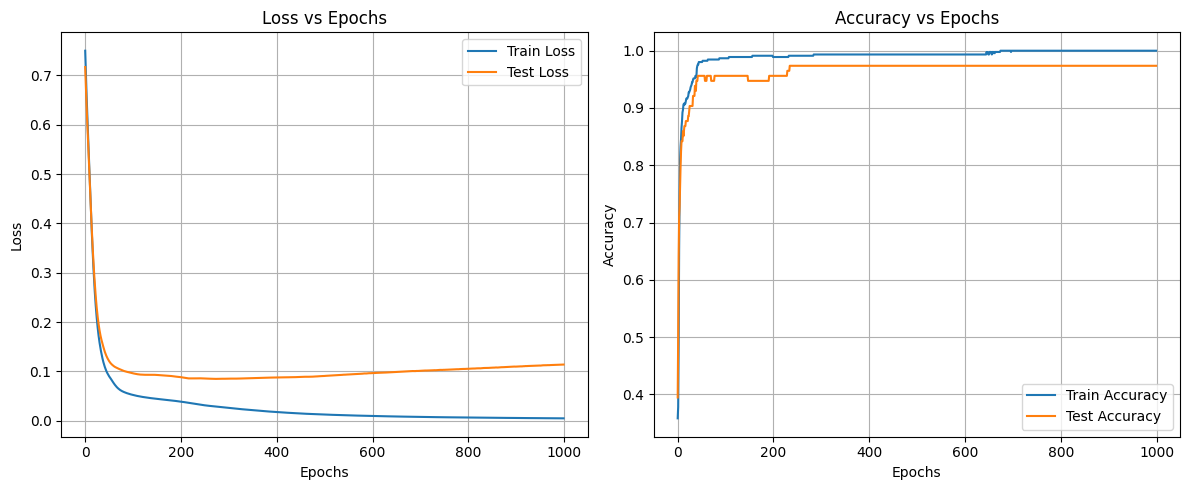

In [7]:
# TODO 11: Visualización de resultados
plt.figure(figsize=(12, 5))

# --- Gráfica 1: Pérdida (Loss) ---
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Loss vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# --- Gráfica 2: Precisión (Accuracy) ---
plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(test_accuracy, label='Test Accuracy')
plt.title('Accuracy vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Ajustar espacios para que no se solapen las etiquetas
plt.tight_layout()
plt.show()

In [8]:
from sklearn.metrics import confusion_matrix as cm

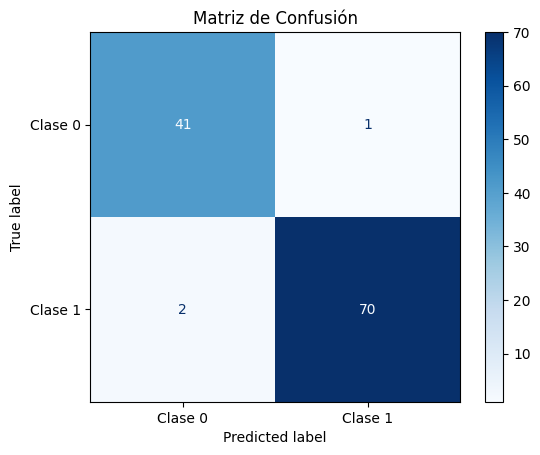

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

with torch.no_grad():
    # TODO 12: Predicciones en test
    test_outputs = model(X_test)
    # Convertimos las probabilidades a clases (0 o 1) usando 0.5 como umbral
    predictions = (test_outputs > 0.5).float()

# TODO 13: Matriz de confusión
# Importante: sklearn trabaja con arrays de NumPy, no tensores de PyTorch.
# Además, usamos .flatten() para asegurarnos de que sean vectores 1D.
y_true = y_test.numpy().flatten()
y_pred = predictions.numpy().flatten()

# Calculamos la matriz
cm = confusion_matrix(y_true, y_pred)

# Visualizamos
# cmap='Blues' le da un tono azulado estándar profesional
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(cmap='Blues')


plt.title("Matriz de Confusión")
plt.show()